# 00_raw_eda · 261240 KODEX 미국달러선물 (slot 20) — ETF Raw EDA

SSOT: `notebooks/_template/00_etf_raw_eda.ipynb` → `scripts/build_notebooks.py` 로 생성. 이 파일을 직접 고치지 말 것.

In [1]:
TICKER = "261240"
SLOT = 20

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
np.random.seed(0)

ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "universe.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("config/universe.csv not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import eda_utils as eu
from src.style import setup_notebook, banner, kpis
setup_notebook()
LIMITATIONS = [eu.LIMITATION_PRICE]
def cap(sec, st, extra=None):
    display(Markdown(eu.caption(sec, st, extra)))

## 00 Identity / Domain Card

In [3]:
U = eu.read_universe(ROOT)
row = U.loc[U["ticker"] == TICKER].iloc[0].to_dict()
banner(f"{TICKER} · {row.get('name','')}", f"UNIVERSE_STATUS={row.get('universe_status','PROVISIONAL') or 'PROVISIONAL'} — 공식 list 입수 시 교체")
display(pd.DataFrame([row]).T.rename(columns={0: "value"}))
KEYF = ["benchmark", "benchmark_proxy_ticker", "currency_hedge", "replication", "trading_hours_note", "structural_notes", "confidence"]
display(pd.DataFrame({"field": KEYF, "value": [row.get(k, "(missing column)") for k in KEYF]}))
print("price policy:", eu.PRICE_POLICY_UNADJ)

,value
slot,20
ticker,261240
name,KODEX 미국달러선물
provider_brand,KODEX (삼성자산운용)
listing_date,2016-12-27
listing_date_source,FDR DataReader first row (proxy; after floor)
data_start,2019-01-02
asset_scope,fx
category,currency
benchmark,미국달러선물 (KRX USD/KRW 선물)


,field,value
0,benchmark,미국달러선물 (KRX USD/KRW 선물)
1,benchmark_proxy_ticker,
2,currency_hedge,n/a (USD 롱 노출이 목적)
3,replication,futures
4,trading_hours_note,KRX same-session (KRX 달러선물 국내 거래)
5,structural_notes,[OBS] Category=7. 원화 약세 시 상승 → 위험자산과 음 상관 기대 [...
6,confidence,high


price policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


### 00 · 이 ETF 는 무엇인가 (ETF-specific)
- **KODEX 미국달러선물 (261240)** · fx / currency · 추종 미국달러선물 (KRX USD/KRW 선물) · 레버리지 none · 환헤지 n/a (USD 롱 노출이 목적) · 복제 futures.
- 거래시간: KRX same-session (KRX 달러선물 국내 거래).
- 비교 기준 ETF(benchmark proxy): 없음 — universe 내 동일 exposure peer 없음 (주식과의 관계는 069500 로 별도 확인).
- UNIVERSE_STATUS=PROVISIONAL · 수익률은 조정가격 수익률(추정, DEC-3).

### ETF-specific reading (A card @efada2e)
**정체성**

- [OBS] asset_scope=fx · category=currency · benchmark=미국달러선물(KRX USD/KRW 선물) · peer_group=fx · replication=futures · KRX 동시간 거래 · confidence=high.
- [ANA] 원화 약세(달러 강세) 때 오르는 구조. 위험회피 시 원화가 약해지므로 주식과 음(−) 상관이 기대된다.

## 01 Raw Data Audit

In [4]:
raw, PROV = eu.load_raw(eu.raw_path(TICKER))
print("price_policy:", PROV["price_policy"])
display(pd.DataFrame([{k: v for k, v in PROV.items() if k != "duplicate_dates"}]).T.rename(columns={0: "value"}))
display(eu.quality_summary(raw))
OHLC_BAD = eu.ohlc_violations(raw); GAPS = eu.date_gaps(raw, 5)
print("OHLC violations:", len(OHLC_BAD)); display(OHLC_BAD.head(10))
print("date gaps > 5 calendar days:", len(GAPS)); display(GAPS)
x, FLAGS = eu.engineer_basic(raw)
HAS_VOL = FLAGS["has_volume"]
if not HAS_VOL: LIMITATIONS.append("no_volume")
if FLAGS["n_zero_volume_days"] > 0: LIMITATIONS.append("zero_volume_days")
if len(x) < 500: LIMITATIONS.append("short_history")
if PROV["n_duplicate_dates"] > 0: LIMITATIONS.append("duplicate_dates")
START, END, N = x["date"].iloc[0], x["date"].iloc[-1], len(x)
ZERO_VOL_RATIO = FLAGS["n_zero_volume_days"] / N
print("first", START.date(), "last", END.date())

price_policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


,value
source_file,/home/sieg/projects-wsl/hongik_univ_26_2/SA/ET...
rows_raw,1903
n_unparseable_dates,0
was_sorted,True
n_duplicate_dates,0
rows_after,1903
price_policy,FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으...
has_adj_close,False
has_volume,True
n_zero_volume_days,0


,column,dtype,n,missing_n,missing_pct,unique_n
0,date,datetime64[us],1903,0,0.0000,1903
1,open,int64,1903,0,0.0000,925
2,high,int64,1903,0,0.0000,908
3,low,int64,1903,0,0.0000,911
4,close,int64,1903,0,0.0000,926
5,volume,int64,1903,0,0.0000,1889
6,change,float64,1903,0,0.0000,1750
7,price,int64,1903,0,0.0000,926


OHLC violations: 0


,date,open,high,low,close


date gaps > 5 calendar days: 9


,date,prev_date,gap_days
0,2019-02-07,2019-02-01,6
1,2020-10-05,2020-09-29,6
2,2021-09-23,2021-09-17,6
3,2022-02-03,2022-01-28,6
4,2023-10-04,2023-09-27,7
5,2024-09-19,2024-09-13,6
6,2025-01-31,2025-01-24,7
7,2025-10-10,2025-10-02,8
8,2026-02-19,2026-02-13,6


first 2019-01-02 last 2026-10-02


In [5]:
extra = [f"가격 정책: {PROV['price_policy']}"]
if not HAS_VOL: extra.append("거래량 컬럼이 없거나 전부 0 → 거래량 기반 분석 생략")
cap("01", {"rows_raw": PROV["rows_raw"], "rows_after": PROV["rows_after"], "n_duplicate_dates": PROV["n_duplicate_dates"],
           "n_unparseable_dates": PROV["n_unparseable_dates"], "was_sorted": PROV["was_sorted"], "ohlc_violations": len(OHLC_BAD),
           "n_gaps_gt5d": len(GAPS), "n_zero_volume_days": FLAGS["n_zero_volume_days"], "zero_vol_ratio": ZERO_VOL_RATIO,
           "first": START.date(), "last": END.date()}, extra)

#### 01 · WHAT WE SEE (raw values)
- `rows_raw` = 1903
- `rows_after` = 1903
- `n_duplicate_dates` = 0
- `n_unparseable_dates` = 0
- `was_sorted` = True
- `ohlc_violations` = 0
- `n_gaps_gt5d` = 9
- `n_zero_volume_days` = 0
- `zero_vol_ratio` = 0
- `first` = 2019-01-02
- `last` = 2026-10-02

#### General note · WHY IT MATTERS
행 수·중복·결측·날짜 공백은 이후 모든 rolling 창과 정렬(merge)의 기준이 된다. 감사되지 않은 행은 전처리 단계에서 조용히 왜곡을 만든다.

#### General note · WHAT WE DO NOT KNOW
- 원천(FDR) 이 휴장일 외의 누락을 어떻게 처리하는지는 이 데이터만으로 확인할 수 없다.
- 가격 정책: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION

#### General note · NEXT QUESTION
- 감사에서 걸린 행(중복/공백/OHLC 위반)을 전처리에서 제거·보간·flag 중 무엇으로 처리할 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 01 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **OHLC 논리 위반일(ohlc_close_gt_high) 0** — 20종 중 공동 4위(17종 동률)(높은 순), 백분위 85% (universe 중앙값 0).
- **|일간 수익률|>15% 점프일 2** — 20종 중 공동 4위(2종 동률)(높은 순), 백분위 85%, 069500 의 2.00배 (universe 중앙값 0).
- **dq_flags 행 수 2** — 20종 중 공동 4위(4종 동률)(높은 순), 백분위 85% (universe 중앙값 0).

- **DQ 각주 · price_anomaly_unverified** (2일): 2019-03-14, 2019-03-15. 통계는 해당일 포함/제외 병기(§03b dq_excluded)

## 02 Whole-History Visual Scan

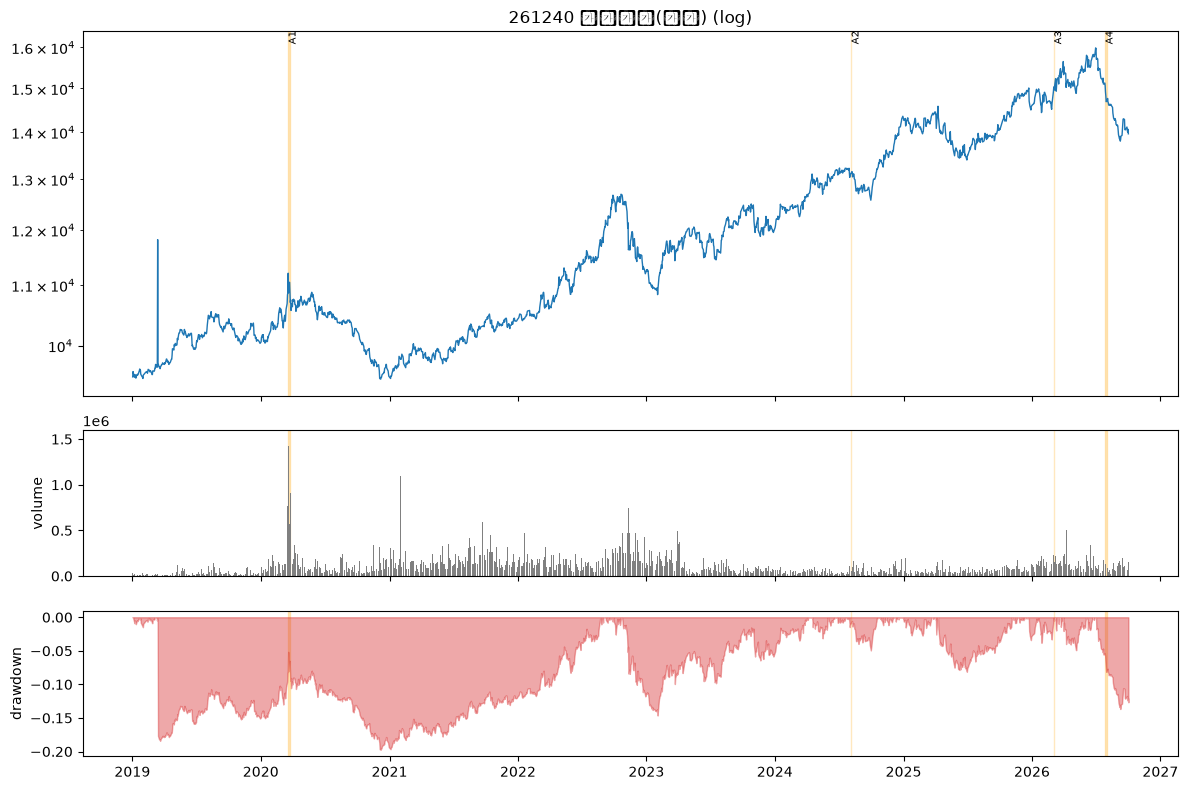

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
ax[0].plot(x["date"], x["price"], lw=1); ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} 조정가격(추정) (log)")
ANCH = eu.read_event_anchors(ROOT)
for _, a in ANCH.iterrows():
    s0, s1 = pd.to_datetime(a["start"], errors="coerce"), pd.to_datetime(a["end"] or a["start"], errors="coerce")
    if pd.notna(s0):
        for axx in ax: axx.axvspan(s0, s1 if pd.notna(s1) else s0, color="orange", alpha=.25)
        ax[0].text(s0, ax[0].get_ylim()[1], a.get("anchor_id", ""), fontsize=7, va="top", rotation=90)
if HAS_VOL: ax[1].bar(x["date"], x["volume"], width=1.5, color="gray")
else: ax[1].text(0.5, 0.5, "no volume", transform=ax[1].transAxes, ha="center")
ax[1].set_ylabel("volume")
ax[2].fill_between(x["date"], x["drawdown"], 0, color="tab:red", alpha=.4); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

In [7]:
cap("02", {"price_first": x["price"].iloc[0], "price_last": x["price"].iloc[-1],
           "price_min": x["price"].min(), "price_max": x["price"].max(), "min_drawdown": x["drawdown"].min(),
           "volume_median": x["volume"].median() if HAS_VOL else "n/a"})

#### 02 · WHAT WE SEE (raw values)
- `price_first` = 9521
- `price_last` = 13965
- `price_min` = 9487
- `price_max` = 15990
- `min_drawdown` = -0.1974
- `volume_median` = 7.373e+04

#### General note · WHY IT MATTERS
전체 이력의 수준·거래량·낙폭을 한 화면에서 보면 구조 변화(regime)나 이상 구간이 있는지, 정규화 창을 어디서 끊어야 할지 판단할 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 가격 점프가 분배금/분할 때문인지 실제 가격 변동인지 이 데이터만으로 구분할 수 없다.

#### General note · NEXT QUESTION
- 전체 기간을 하나의 정규화 창으로 볼 수 있는가, 아니면 구간을 나눠야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 02 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **기간 누적 가격 변화(2019-01-02→최종일, 조정가격 추정) +46.7%** — 20종 중 15위(높은 순), 백분위 30%, 069500 의 0.12배 (universe 중앙값 +140.3%).

## 03 Return Distribution

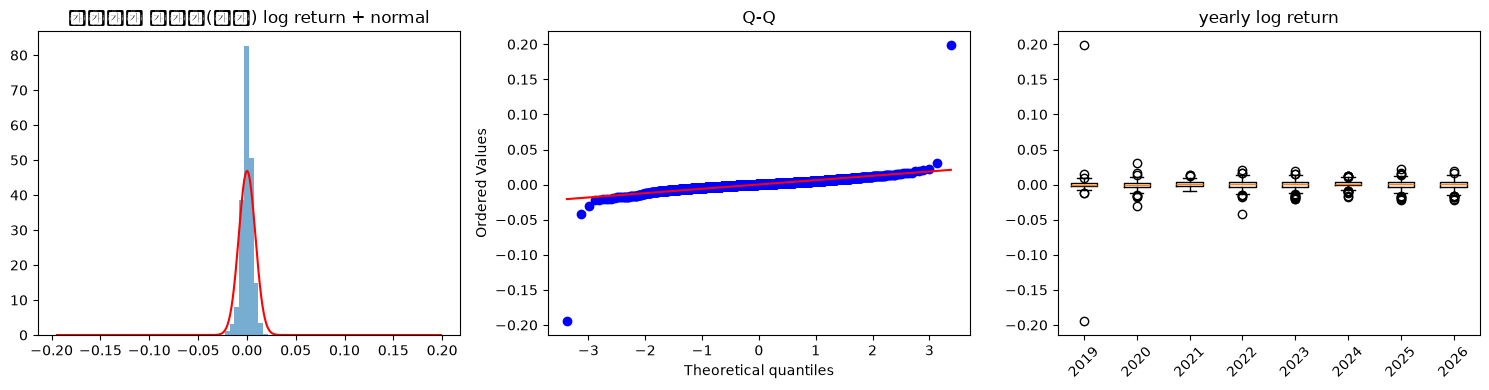

In [8]:
r = x["log_ret"].dropna()
K = {"mean": r.mean(), "std": r.std(), "ann_vol": r.std() * np.sqrt(252), "skew": stats.skew(r),
     "ex_kurt": stats.kurtosis(r), "ex_kurt_trim3": eu.kurt_trim(r, 3), "p01": r.quantile(.01), "p99": r.quantile(.99), "n": len(r)}
kpis([(k, f"{v:.4g}") for k, v in K.items()])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(r, bins=80, density=True, alpha=.6); g = np.linspace(r.min(), r.max(), 300)
ax[0].plot(g, stats.norm.pdf(g, r.mean(), r.std()), "r-"); ax[0].set_title("조정가격 수익률(추정) log return + normal")
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q")
yr = x.dropna(subset=["log_ret"]).groupby(x["date"].dt.year)["log_ret"]
ax[2].boxplot([v.values for _, v in yr], tick_labels=[str(k) for k, _ in yr]); ax[2].set_title("yearly log return")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [9]:
cap("03", K)

#### 03 · WHAT WE SEE (raw values)
- `mean` = 0.0002014
- `std` = 0.008498
- `ann_vol` = 0.1349
- `skew` = 0.2251
- `ex_kurt` = 300.3
- `ex_kurt_trim3` = 2.423
- `p01` = -0.01719
- `p99` = 0.01388
- `n` = 1902

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03b Core stats — full / by year / 2026-07-20~08-10 제외 / DQ 포함 vs 제외

In [10]:
SV, DQ_NOTE = eu.stats_variants(x, ROOT, TICKER)
display(SV); print("DQ:", DQ_NOTE)
if DQ_NOTE != "no_dq_flags": LIMITATIONS.append("dq_flagged_dates")  # 해당일 포함/제외 병기됨
exk = [i for i in SV.index if i.startswith("excl_")][0]
cap("03", {"full_ann_vol": SV.loc["full", "ann_vol"], "excl_window_ann_vol": SV.loc[exk, "ann_vol"],
           "full_ex_kurt": SV.loc["full", "ex_kurt"], "excl_window_ex_kurt": SV.loc[exk, "ex_kurt"],
           "dq_excluded_ex_kurt": SV.loc["dq_excluded", "ex_kurt"], "dq_note": DQ_NOTE,
           "year_ann_vol_min": SV.filter(like="year_", axis=0)["ann_vol"].min(), "year_ann_vol_max": SV.filter(like="year_", axis=0)["ann_vol"].max()})

,n,ann_vol,ex_kurt,ex_kurt_trim3,p01,p99,max_dd
full,"1,902.0000",0.1349,300.3005,2.4235,-0.0172,0.0139,-0.1974
year_2019,245.0000,0.2893,108.6681,0.4263,-0.0103,0.0099,-0.1840
year_2020,248.0000,0.0941,5.3000,0.7727,-0.0166,0.0126,-0.1538
year_2021,248.0000,0.0636,0.4195,-0.4744,-0.0078,0.0112,-0.0311
year_2022,246.0000,0.1077,5.9971,0.2741,-0.0159,0.0150,-0.1178
year_2023,245.0000,0.1002,1.2581,0.8471,-0.0185,0.0143,-0.0505
year_2024,244.0000,0.0754,1.2771,0.2582,-0.0110,0.0119,-0.0494
year_2025,242.0000,0.0932,2.5992,1.4816,-0.0183,0.0144,-0.0812
year_2026,184.0000,0.1093,0.7838,0.3669,-0.0179,0.0143,-0.1366
excl_2026-07-20~2026-08-10,"1,886.0000",0.1352,299.7741,2.4514,-0.0172,0.0139,-0.1974


DQ: price_anomaly_unverified rows=2, distinct dates=2


#### 03 · WHAT WE SEE (raw values)
- `full_ann_vol` = 0.1349
- `excl_window_ann_vol` = 0.1352
- `full_ex_kurt` = 300.3
- `excl_window_ex_kurt` = 299.8
- `dq_excluded_ex_kurt` = 3.855
- `dq_note` = price_anomaly_unverified rows=2, distinct dates=2
- `year_ann_vol_min` = 0.06361
- `year_ann_vol_max` = 0.2893

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **연환산 변동성 13.5%** — 20종 중 18위(높은 순), 백분위 15%, 069500 의 0.47배 (universe 중앙값 28.4%).
- **초과첨도(full) 300.3** — 20종 중 2위(높은 순), 백분위 95%, 069500 의 15.80배 (universe 중앙값 10.5).
- **초과첨도(상위 |r| 3일 제외) 2.4** — 20종 중 19위(높은 순), 백분위 10%, 069500 의 0.31배 (universe 중앙값 3.9).
- **왜도 +0.23** — 20종 중 4위(높은 순), 백분위 85%, 069500 의 1.37배 (universe 중앙값 -0.11).
- **일간 로그수익률 1% 분위 -1.72%** — 20종 중 18위(낮은(더 극단) 순), 백분위 15%, 069500 의 0.29배 (universe 중앙값 -5.18%).
- **일간 로그수익률 99% 분위 +1.39%** — 20종 중 18위(높은 순), 백분위 15%, 069500 의 0.26배 (universe 중앙값 +5.15%).

- **DQ 각주 · price_anomaly_unverified** (2일): 2019-03-14, 2019-03-15. 통계는 해당일 포함/제외 병기(§03b dq_excluded)

### ETF-specific reading (A card @efada2e)
**평소 움직임**

- [OBS] ann_vol 포함 13.49% / **제외 8.92%** (_exw 13.52%) · skew 0.23 / 제외 −0.50 · ex_kurt full **300.3** / 쌍 제외 **3.86** / trim3 2.42 (_exw 299.8) · q01 −1.72% / q99 +1.39% · |r| q95 1.17% / q99 1.77%.
- [OBS] max_up 포함 +19.87%(2019-03-14) / 제외 **+3.05%(2020-03-19)** · max_dn 포함 −19.46%(2019-03-15) / 제외 −4.25%(2022-11-11).
- [OBS] 연도별 ann vol: 2019 28.9%(쌍 제외 6.2%) · 2020 9.4% · 2021 6.4% · 2022 10.8% · 2023 10.0% · 2024 7.5% · 2025 9.3% · 2026 10.9%.

## 04 Volatility Dynamics

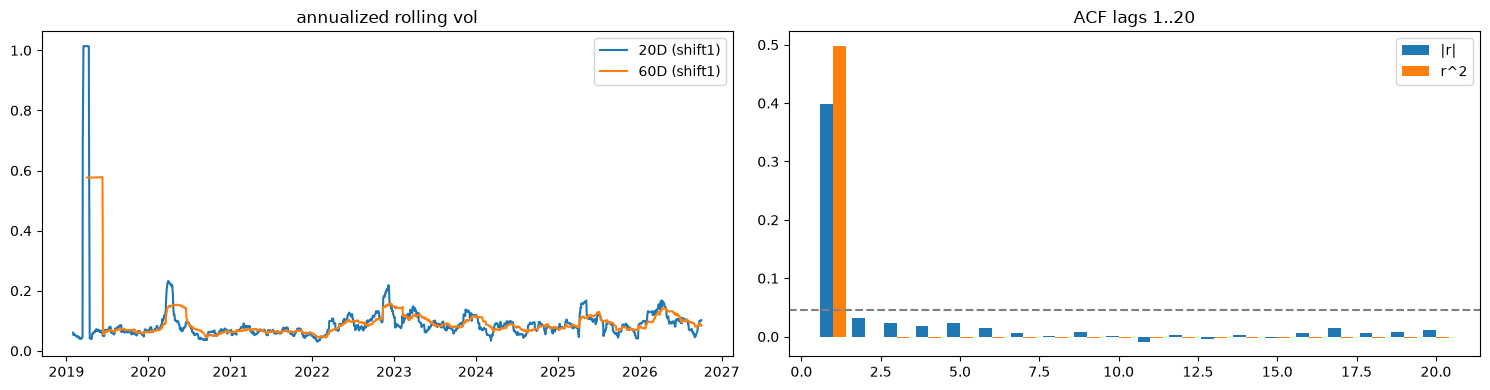

,lag,acf_absret,acf_sqret
0,1,0.3992,0.4976
1,2,0.0324,-0.0015
2,3,0.0232,-0.0019
3,4,0.0176,-0.0017
4,5,0.0234,-0.0017
5,6,0.0140,-0.0019
6,7,0.0064,-0.0022
7,8,0.0019,-0.0024
8,9,0.0072,-0.0019
9,10,0.0010,-0.0022


,lb_stat,lb_pvalue
5,308.1940,0.0000
10,308.7553,0.0000
20,309.8250,0.0000


In [11]:
ACF_ABS = eu.acf(x["abs_ret"], 20); ACF_SQ = eu.acf(x["log_ret"] ** 2, 20)
VOL_OF_VOL = float((x["roll_vol_20"] / x["roll_vol_20"].mean()).std())
from statsmodels.stats.diagnostic import acorr_ljungbox
LB = acorr_ljungbox(x["abs_ret"].dropna(), lags=[5, 10, 20])
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(x["date"], x["roll_vol_20"] * np.sqrt(252), label="20D (shift1)")
ax[0].plot(x["date"], x["roll_vol_60"] * np.sqrt(252), label="60D (shift1)"); ax[0].legend(); ax[0].set_title("annualized rolling vol")
lags = np.arange(1, 21)
ax[1].bar(lags - .2, ACF_ABS, .4, label="|r|"); ax[1].bar(lags + .2, ACF_SQ, .4, label="r^2")
ax[1].axhline(1.96 / np.sqrt(len(x)), ls="--", c="gray"); ax[1].legend(); ax[1].set_title("ACF lags 1..20")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag": lags, "acf_absret": ACF_ABS, "acf_sqret": ACF_SQ}).head(10)); display(LB)

In [12]:
cap("04", {"acf_absret_lag1": ACF_ABS[0], "acf_absret_lag5": ACF_ABS[4], "acf_sqret_lag1": ACF_SQ[0],
           "vol_of_vol(cv of roll_vol_20)": VOL_OF_VOL, "ljungbox_absret_lag20_p": LB["lb_pvalue"].iloc[-1],
           "roll_vol_20_ann_median": x["roll_vol_20"].median() * np.sqrt(252)})

#### 04 · WHAT WE SEE (raw values)
- `acf_absret_lag1` = 0.3992
- `acf_absret_lag5` = 0.02339
- `acf_sqret_lag1` = 0.4976
- `vol_of_vol(cv of roll_vol_20)` = 1.065
- `ljungbox_absret_lag20_p` = 7.928e-54
- `roll_vol_20_ann_median` = 0.07744

#### General note · WHY IT MATTERS
변동성 군집(|r|, r^2 의 자기상관)이 있으면 고정 임계값보다 시간가변 baseline 정규화가 필요하다는 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 표본이 크면 Ljung-Box 는 작은 자기상관도 유의하게 만든다 — 유의성은 크기의 증거가 아니다.

#### General note · NEXT QUESTION
- baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 04 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|r| lag1 자기상관(변동성 군집) 0.399** — 20종 중 2위(높은 순), 백분위 95%, 069500 의 1.05배 (universe 중앙값 0.302).
- **vol-of-vol 1.065** — 20종 중 2위(높은 순), 백분위 95%, 069500 의 1.41배 (universe 중앙값 0.544).

### ETF-specific reading (A card @efada2e)
**변동성 구조**

- [OBS] acf_abs1/5/20 = 0.399 / 0.023 / 0.011 · acf_r1 −0.292 · 20D rolling vol median 7.75%, p90/p10 2.40 · vol_ratio_hi_lo 2.63. 60D vol 최고 57.8%(2019-06-03, 이상치 포함 창).
- [ANA] acf_r1 −0.29·acf_abs1 0.40 은 대부분 2019-03 반전 한 쌍이 만든 값으로 보임(lag5 부터 ~0). 실제 FX 변동성 군집은 약하다.

## 05 Trading Activity

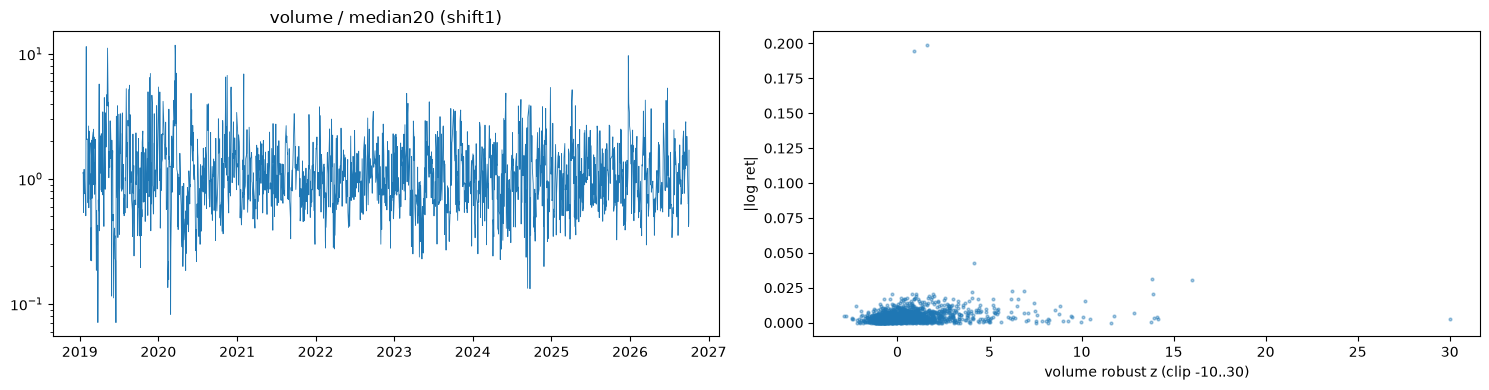

In [13]:
VOLST = {}
if HAS_VOL:
    vz = x["volume_robust_z_20"]
    rho, p = stats.spearmanr(x["abs_ret"], vz, nan_policy="omit")
    ext = x["abs_q95"].fillna(False)
    VOLST = {"spearman_absret_volz": rho, "spearman_p": p, "volz_median_extreme(abs_q95)": vz[ext].median(),
             "volz_median_normal": vz[~ext].median(), "volratio_median_extreme": x["volume_ratio_20"][ext].median(),
             "volratio_median_normal": x["volume_ratio_20"][~ext].median(), "n_mad_zero": FLAGS["n_mad_zero"]}
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(x["date"], x["volume_ratio_20"], lw=.6); ax[0].set_yscale("log"); ax[0].set_title("volume / median20 (shift1)")
    ax[1].scatter(vz.clip(-10, 30), x["abs_ret"], s=4, alpha=.4); ax[1].set_xlabel("volume robust z (clip -10..30)"); ax[1].set_ylabel("|log ret|")
    plt.tight_layout(); plt.show()
else:
    print("SKIP: 거래량 없음 (has_volume=False)")
    VOLST = {"skipped": "no_volume"}

In [14]:
cap("05", VOLST, None if HAS_VOL else ["거래량이 없어 이 절 분석을 생략했다."])

#### 05 · WHAT WE SEE (raw values)
- `spearman_absret_volz` = 0.278
- `spearman_p` = 8.703e-35
- `volz_median_extreme(abs_q95)` = 1.642
- `volz_median_normal` = -0.04222
- `volratio_median_extreme` = 1.763
- `volratio_median_normal` = 0.9796
- `n_mad_zero` = 0

#### General note · WHY IT MATTERS
거래량 baseline(shift(1))과 수익률 크기의 관계는 거래량을 극단 후보의 보조 신호로 쓸 수 있는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 거래량 급증의 원인(설정/환매, LP 호가, 리밸런싱)은 이 데이터에 없다.

#### General note · NEXT QUESTION
- 거래량 robust z 를 극단 후보의 보조 조건으로 쓸 가치가 있는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 05 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **일 거래대금 중앙값(Close×Volume, 억원) 8.8** — 20종 중 18위(높은 순), 백분위 15%, 069500 의 0.00배 (universe 중앙값 31.2).
- **일 거래량 중앙값(주) 73,728** — 20종 중 15위(높은 순), 백분위 30%, 069500 의 0.01배 (universe 중앙값 169,876).

### ETF-specific reading (A card @efada2e)
**거래활동**

- [OBS] med_volume 73,728주 · zero_vol_days 0 · corr(|r|, Δlog vol) 0.237 · 극단일(|rz|>3) volume ratio ≥2 동반률 47% (기준선 14%).

## 06 Drawdown / Recovery / Persistence

In [15]:
EP = eu.drawdown_episodes(x["price"], x["date"], 5)
i_min = int(x["drawdown"].idxmin()); MAX_DD = float(x["drawdown"].min()); MAX_DD_DATE = x["date"].iloc[i_min].date()
rec = x.index[(x.index > i_min) & (x["drawdown"] >= 0)]
RECOVERY_DAYS = int((x["date"].iloc[rec[0]] - x["date"].iloc[i_min]).days) if len(rec) else None
display(EP)
lp = np.log(x["price"])
fw = {}
for h in (1, 3, 5, 10):
    f = lp.shift(-h) - lp
    fw[h] = {"pos_q95": f[x["pos_q95"]].mean(), "neg_q05": f[x["neg_q05"]].mean(), "all": f.mean()}
FWD = pd.DataFrame(fw).T.rename_axis("h"); display(FWD)
print("※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).")

,peak_date,trough_date,depth,recovery_date,recovery_days
0,2019-03-14,2020-12-07,-0.1974,2022-08-23,624.0000
1,2022-10-21,2023-02-02,-0.1463,2024-04-05,428.0000
2,2026-07-01,2026-09-09,-0.1366,None,NaN
3,2025-04-09,2025-06-30,-0.0812,2025-11-05,128.0000
4,2024-07-03,2024-09-30,-0.0494,2024-10-21,21.0000


,pos_q95,neg_q05,all
h,,,
1,-0.0025,0.0009,0.0002
3,-0.0022,0.0008,0.0006
5,-0.0006,0.0019,0.0010
10,0.0018,0.0032,0.0021


※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).


In [16]:
cap("06", {"max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS if RECOVERY_DAYS is not None else "not recovered",
           "fwd5_after_pos_q95": FWD.loc[5, "pos_q95"], "fwd5_after_neg_q05": FWD.loc[5, "neg_q05"], "fwd5_all": FWD.loc[5, "all"]})

#### 06 · WHAT WE SEE (raw values)
- `max_dd` = -0.1974
- `max_dd_date` = 2020-12-07
- `recovery_days` = 624
- `fwd5_after_pos_q95` = -0.0006375
- `fwd5_after_neg_q05` = 0.001909
- `fwd5_all` = 0.001014

#### General note · WHY IT MATTERS
낙폭 깊이·회복 기간·극단일 이후 forward return 은 이벤트 창 길이와 사후 관측 구간 설계의 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- forward return 은 겹치는 표본(overlapping)이라 독립 관측 수가 실제보다 적다. 인과가 아니다.

#### General note · NEXT QUESTION
- 극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 06 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **최대 낙폭 -19.7%** — 20종 중 19위(낮은(더 극단) 순), 백분위 10%, 069500 의 0.48배 (universe 중앙값 -47.5%).
- **최대 낙폭 회복일수 624** — 12종 중 5위(높은 순), 백분위 40% (universe 중앙값 377).

### ETF-specific reading (A card @efada2e)
**언제 이상해지는가**

- [OBS] max_dd −19.7%: peak 2019-03-14(이상치 종가 11,820) → trough 2020-12-07 → 회복 2022-08-23 (422 거래일). last_dd −12.7%.
- [ANA] 이 max_dd 는 이상치 고점에서 시작하므로 실제 손실폭을 과대평가 → 쌍 제외 재계산 필요.

## 07 Candidate Extreme Windows

최종 label/threshold 아님. z 후보는 shift(1) baseline, q 후보는 full-sample(look-ahead).

,definition,n_days
0,pos_z2,64
1,neg_z2,76
2,abs_z2,140
3,pos_z2_5,25
4,neg_z2_5,38
5,abs_z2_5,63
6,pos_z3,15
7,neg_z3,17
8,abs_z3,32
9,pos_q95,96


,abs_z2,abs_z2_5,abs_z3,abs_q95
abs_z2,1.0000,0.4500,0.2286,0.3882
abs_z2_5,0.4500,1.0000,0.5079,0.3947
abs_z3,0.2286,0.5079,1.0000,0.2549
abs_q95,0.3882,0.3947,0.2549,1.0000


,date,price,log_ret,ret_z20,roll_vol_20
47,2019-03-14,11820,0.1987,68.7660,0.0029
1538,2025-04-04,14084,-0.0226,-7.8516,0.0029
1715,2025-12-24,14703,-0.0207,-7.8483,0.0026
953,2022-11-11,11632,-0.0425,-6.4831,0.0066
425,2020-09-18,10165,-0.0116,-5.1889,0.0022
1388,2024-08-19,12761,-0.0177,-4.5803,0.0039
48,2019-03-15,9730,-0.1946,-4.3843,0.0444
1278,2024-03-08,12340,-0.0092,-4.3666,0.0021
512,2021-01-28,9834,0.0142,4.2214,0.0034
146,2019-08-05,10492,0.0157,4.1436,0.0038


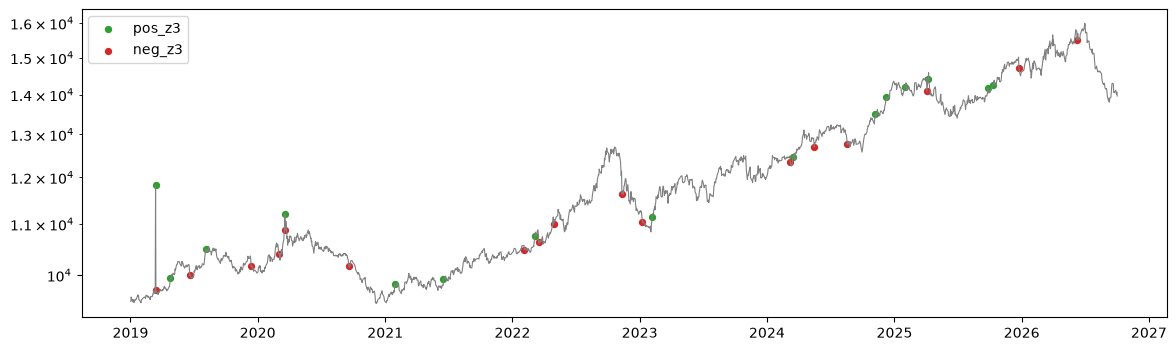

In [17]:
DEFS = [c for c in x.columns if c.startswith(("pos_z", "neg_z", "abs_z")) or c in ("pos_q95", "neg_q05", "abs_q95")]
CNT = pd.DataFrame({"definition": DEFS, "n_days": [int(x[c].sum()) for c in DEFS]}); display(CNT)
absdefs = ["abs_z2", "abs_z2_5", "abs_z3", "abs_q95"]
JAC = pd.DataFrame([[eu.jaccard(x[a], x[b]) for b in absdefs] for a in absdefs], index=absdefs, columns=absdefs); display(JAC)
TOP = x.loc[x["ret_z20"].abs().nlargest(10).index, ["date", "price", "log_ret", "ret_z20", "roll_vol_20"]]; display(TOP)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(x["date"], x["price"], lw=.8, c="gray"); ax.set_yscale("log")
ax.scatter(x["date"][x["pos_z3"]], x["price"][x["pos_z3"]], c="tab:green", s=18, label="pos_z3")
ax.scatter(x["date"][x["neg_z3"]], x["price"][x["neg_z3"]], c="tab:red", s=18, label="neg_z3"); ax.legend(); plt.show()
N_POS3, N_NEG3, N_ABS3 = int(x["pos_z3"].sum()), int(x["neg_z3"].sum()), int(x["abs_z3"].sum())

### 07b 정의별 극단일 표 (① abs% q95 ② shift(1) robust z w60 k3 ③ percentile q01/q99)

In [18]:
XDEF, XSC = eu.extreme_definitions(x)
for nm, msk in XDEF.items():
    t = x.loc[msk, ["date", "ret_1d", "log_ret"]].assign(score=XSC[nm][msk])
    print(f"[{nm}] n_days={int(msk.sum())}"); display(t.nlargest(10, "score"))
ks = list(XDEF)
JAC3 = {f"{ks[i]}~{ks[j]}": eu.jaccard(XDEF[ks[i]], XDEF[ks[j]]) for i in range(3) for j in range(i + 1, 3)}
print("Jaccard: " + " | ".join(f"{k}={v:.3f}" for k, v in JAC3.items()))

[abs_pct_q95] n_days=96


,date,ret_1d,log_ret,score
47,2019-03-14,0.2198,0.1987,0.2198
48,2019-03-15,-0.1768,-0.1946,0.1768
953,2022-11-11,-0.0416,-0.0425,0.0416
299,2020-03-19,0.0310,0.0305,0.0310
300,2020-03-20,-0.0305,-0.0310,0.0305
1539,2025-04-07,0.0232,0.0230,0.0232
1538,2025-04-04,-0.0224,-0.0226,0.0224
1783,2026-04-08,-0.0215,-0.0217,0.0215
970,2022-12-06,0.0208,0.0206,0.0208
1715,2025-12-24,-0.0205,-0.0207,0.0205


[robust_z_shift1_w60_k3] n_days=62


,date,ret_1d,log_ret,score
1388,2024-08-19,-0.0176,-0.0177,6.3639
790,2022-03-17,-0.0165,-0.0166,6.0878
1538,2025-04-04,-0.0224,-0.0226,5.8203
1715,2025-12-24,-0.0205,-0.0207,5.7937
953,2022-11-11,-0.0416,-0.0425,5.5361
1539,2025-04-07,0.0232,0.0230,5.5267
300,2020-03-20,-0.0305,-0.0310,5.5235
299,2020-03-19,0.0310,0.0305,5.3669
1735,2026-01-26,-0.0165,-0.0166,5.0678
1757,2026-03-03,0.0195,0.0193,5.0384


[pctile_q01_q99] n_days=40


,date,ret_1d,log_ret,score
47,2019-03-14,0.2198,0.1987,0.2198
48,2019-03-15,-0.1768,-0.1946,0.1768
953,2022-11-11,-0.0416,-0.0425,0.0416
299,2020-03-19,0.0310,0.0305,0.0310
300,2020-03-20,-0.0305,-0.0310,0.0305
1539,2025-04-07,0.0232,0.0230,0.0232
1538,2025-04-04,-0.0224,-0.0226,0.0224
1783,2026-04-08,-0.0215,-0.0217,0.0215
970,2022-12-06,0.0208,0.0206,0.0208
1715,2025-12-24,-0.0205,-0.0207,0.0205


Jaccard: abs_pct_q95~robust_z_shift1_w60_k3=0.436 | abs_pct_q95~pctile_q01_q99=0.417 | robust_z_shift1_w60_k3~pctile_q01_q99=0.397


In [19]:
cap("07", {"n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3, "n_abs_z2": int(x["abs_z2"].sum()),
           "n_abs_q95": int(x["abs_q95"].sum()), "jaccard_abs_z3_vs_abs_q95": JAC.loc["abs_z3", "abs_q95"],
           "jaccard_abs_z2_vs_abs_z3": JAC.loc["abs_z2", "abs_z3"], **{f"n_{k}": int(v.sum()) for k, v in XDEF.items()}, **{f"jac_{k}": v for k, v in JAC3.items()}, "max_abs_ret_z20": x["ret_z20"].abs().max()})

#### 07 · WHAT WE SEE (raw values)
- `n_pos_z3` = 15
- `n_neg_z3` = 17
- `n_abs_z3` = 32
- `n_abs_z2` = 140
- `n_abs_q95` = 96
- `jaccard_abs_z3_vs_abs_q95` = 0.2549
- `jaccard_abs_z2_vs_abs_z3` = 0.2286
- `n_abs_pct_q95` = 96
- `n_robust_z_shift1_w60_k3` = 62
- `n_pctile_q01_q99` = 40
- `jac_abs_pct_q95~robust_z_shift1_w60_k3` = 0.4364
- `jac_abs_pct_q95~pctile_q01_q99` = 0.4167
- `jac_robust_z_shift1_w60_k3~pctile_q01_q99` = 0.3973
- `max_abs_ret_z20` = 68.77

#### General note · WHY IT MATTERS
후보 정의마다 선택되는 날이 얼마나 겹치는지는 극단 정의가 정의 선택에 얼마나 민감한지를 보여준다 (최종 정의는 여기서 정하지 않는다).

#### General note · WHAT WE DO NOT KNOW
- q95/q05 후보는 전체표본 분위수(look-ahead) 이므로 실시간 탐지에는 쓸 수 없다.

#### General note · NEXT QUESTION
- 후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 07 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|z|≥3 후보일(shift(1) 20D vol 기준) 32** — 20종 중 공동 15위(2종 동률)(높은 순), 백분위 30%, 069500 의 0.97배 (universe 중앙값 34).
- **z≥+3 후보일 15** — 20종 중 공동 8위(2종 동률)(높은 순), 백분위 65%, 069500 의 1.25배 (universe 중앙값 14).
- **z≤−3 후보일 17** — 20종 중 공동 14위(4종 동률)(높은 순), 백분위 35%, 069500 의 0.81배 (universe 중앙값 19).

- **DQ 각주 · price_anomaly_unverified** (2일): 2019-03-14, 2019-03-15. 통계는 해당일 포함/제외 병기(§03b dq_excluded)

### ETF-specific reading (A card @efada2e)
**언제 이상해지는가**

- [OBS] 상위 |robust-z(shift1)| (정의: (r−직전252일 median)/(1.4826·MAD), min 60; 2019-03 은 min_periods 미달로 rz 없음, trailing-std z +23.4/−22.9) — 날짜 · r · rz · universe median · vol ratio:
  2022-11-11 −4.25% · −9.6 · +2.88%(공통, 같은방향 11개) · 2.7배 | 2020-03-20 −3.10% · −8.5 · +7.29%(공통) · 10.9배 | 2020-03-19 +3.05% · +8.2 · −7.97%(공통) · 11.7배 | 2025-04-04 −2.26% · −6.0 · −0.76%(고유) · 4.0배 | 2025-04-07 +2.30% · +5.6 · −5.90%(공통) · 5.2배.
- [OBS] |rz|>3 일수 60 (_exw 60). 쌍 제외 시 극단일은 모두 universe median 과 **반대 방향**.

## 08 Benchmark / Peer Relationship

In [20]:
BETA = CORR = None; BST = {}
bm = row.get("benchmark_proxy_ticker", "")
print("benchmark (index name):", row.get("benchmark", ""), "| proxy ticker:", bm or "(none)")
if bm and bm != TICKER and eu.raw_path(bm).exists():
    b, _ = eu.load_raw(eu.raw_path(bm)); b, _ = eu.engineer_basic(b)
    m = x[["date", "log_ret"]].merge(b[["date", "log_ret"]], on="date", how="outer", suffixes=("", "_bm"), indicator=True)
    n_unm = int((m["_merge"] != "both").sum()); mm = m[m["_merge"] == "both"].dropna(subset=["log_ret", "log_ret_bm"]).sort_values("date")
    BETA = float(np.cov(mm["log_ret"], mm["log_ret_bm"])[0, 1] / mm["log_ret_bm"].var()); CORR = float(mm["log_ret"].corr(mm["log_ret_bm"]))
    rc = mm["log_ret"].rolling(60).corr(mm["log_ret_bm"])
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(mm["date"], rc); ax[0].set_title(f"60D rolling corr vs {bm}")
    ax[1].plot(mm["date"], (mm["log_ret"] - mm["log_ret_bm"]).cumsum()); ax[1].set_title("cumulative excess log return")
    plt.tight_layout(); plt.show()
    BST = {"benchmark": bm, "n_unmatched_dates": n_unm, "n_matched": len(mm), "beta": BETA, "corr": CORR, "rolling_corr60_min": rc.min()}
else:
    reason = "benchmark_proxy_ticker 미지정" if not bm else ("self" if bm == TICKER else "benchmark raw 없음")
    print("SKIP benchmark:", reason); BST = {"benchmark_skip": reason}
    if bm and bm != TICKER: LIMITATIONS.append("benchmark_missing")  # proxy 미지정(기준 자체·비주식)은 설계상 정상
pg = row.get("peer_group", "")
peers = [t for t in U.loc[(U["peer_group"] == pg) & (U["ticker"] != TICKER), "ticker"] if pg and eu.raw_path(t).exists()]
if peers:
    rets = {TICKER: x.set_index("date")["log_ret"]}
    for t in peers:
        d, _ = eu.load_raw(eu.raw_path(t)); d, _ = eu.engineer_basic(d); rets[t] = d.set_index("date")["log_ret"]
    PC = pd.DataFrame(rets).corr(); display(PC); BST["n_peers"] = len(peers); BST["peer_corr_mean"] = PC[TICKER].drop(TICKER).mean()
else:
    print("peer 없음 (peer_group=", pg, ")")

benchmark (index name): 미국달러선물 (KRX USD/KRW 선물) | proxy ticker: (none)
SKIP benchmark: benchmark_proxy_ticker 미지정
peer 없음 (peer_group= fx )


In [21]:
cap("08", BST)

#### 08 · WHAT WE SEE (raw values)
- `benchmark_skip` = benchmark_proxy_ticker 미지정

#### General note · WHY IT MATTERS
벤치마크·peer 와의 동조성은 개별 ETF 신호와 시장 공통 신호를 분리(초과수익 정규화)해야 하는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- benchmark 는 universe 내 대리 ticker 이며 공식 추종지수 자체가 아닐 수 있다.

#### General note · NEXT QUESTION
- 극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 08 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- benchmark proxy 와 상관: 값 없음 (해당 없음 또는 계산 불가).
- benchmark proxy 대비 beta: 값 없음 (해당 없음 또는 계산 불가).

### ETF-specific reading (A card @efada2e)
**peer 와 다른 점**

> 카드에 이 섹션 없음

## 09 Multivariate Structure (diagnostic)

,pc,explained_ratio
0,PC1,0.4587
1,PC2,0.2854
2,PC3,0.1178
3,PC4,0.0813


pc,PC1,PC2,PC3,PC4
log_ret,-0.0456,0.1964,0.8143,0.0920
abs_ret,0.0921,0.6369,-0.4840,-0.2254
roll_vol_20,0.9937,-0.0731,0.0697,0.0450
drawdown,-0.0162,0.0268,0.0285,-0.0308
range_pct,0.0360,0.7294,0.2445,0.0008
volume_robust_z_20,-0.0210,0.1333,-0.1926,0.9684


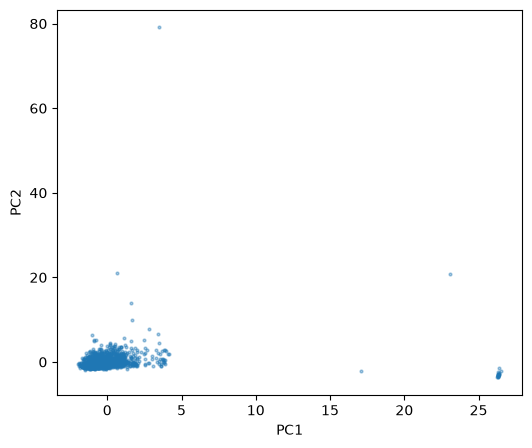

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
feats = ["log_ret", "abs_ret", "roll_vol_20", "drawdown"] + (["range_pct"] if "range_pct" in x else []) + (["volume_robust_z_20"] if HAS_VOL else [])
F = x[feats].replace([np.inf, -np.inf], np.nan).dropna()
Z = RobustScaler().fit_transform(F); pca = PCA(n_components=min(len(feats), 4), random_state=0).fit(Z)
EVR = pd.DataFrame({"pc": [f"PC{i+1}" for i in range(pca.n_components_)], "explained_ratio": pca.explained_variance_ratio_}); display(EVR)
LOAD = pd.DataFrame(pca.components_.T, index=feats, columns=EVR["pc"]); display(LOAD)
S = pca.transform(Z); plt.figure(figsize=(6, 5)); plt.scatter(S[:, 0], S[:, 1], s=4, alpha=.4); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
PC1 = float(pca.explained_variance_ratio_[0])

In [23]:
cap("09", {"n_rows_used": len(F), "features": ", ".join(feats), "pc1_ratio": PC1, "pc2_ratio": float(pca.explained_variance_ratio_[1]),
           "pc1_top_loading": LOAD["PC1"].abs().idxmax()})

#### 09 · WHAT WE SEE (raw values)
- `n_rows_used` = 1882
- `features` = log_ret, abs_ret, roll_vol_20, drawdown, range_pct, volume_robust_z_20
- `pc1_ratio` = 0.4587
- `pc2_ratio` = 0.2854
- `pc1_top_loading` = roll_vol_20

#### General note · WHY IT MATTERS
여러 feature 가 소수의 축으로 요약되는지는 다변량 정규화·차원 축소가 필요한지에 대한 진단이다.

#### General note · WHAT WE DO NOT KNOW
- PCA 는 선형·전체표본 진단이며, 축의 의미를 확정하지 않는다.

#### General note · NEXT QUESTION
- PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 09 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **PCA PC1 설명비율 45.9%** — 20종 중 14위(높은 순), 백분위 35%, 069500 의 0.85배 (universe 중앙값 50.2%).

## 10 Questions Discovered (SEED only — ACCEPTED/REJECTED 금지)

In [24]:
Q = []
def seed(cond, scope, stmt, ev):
    if cond: Q.append({"id": f"{TICKER}-Q{len(Q)+1:02d}", "scope": scope, "statement": stmt, "status": "SEED", "evidence": ev})
seed(K["ex_kurt"] > 5 and K["ex_kurt_trim3"] > 5, "distribution", "꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다", f"ex_kurt={K['ex_kurt']:.2f}, trim3={K['ex_kurt_trim3']:.2f}")
seed(ZERO_VOL_RATIO > .01, "volume", "거래량 0 일이 많아 거래량 baseline 이 불안정할 수 있다", f"zero_vol_ratio={ZERO_VOL_RATIO:.3f}")
seed(MAX_DD < -.30, "drawdown", "깊은 낙폭 구간이 정규화 창을 지배할 수 있다", f"max_dd={MAX_DD:.3f}")
seed(abs(ACF_ABS[0]) > .2, "volatility", "변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다", f"acf_absret_lag1={ACF_ABS[0]:.3f}")
seed(not HAS_VOL, "volume", "거래량 부재 — 거래량 기반 후보 정의 불가", "has_volume=False")
seed(CORR is not None and CORR > .9, "benchmark", "benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토", f"corr={CORR}")
QT = pd.DataFrame(Q, columns=["id", "scope", "statement", "status", "evidence"]); display(QT)

,id,scope,statement,status,evidence
0,261240-Q01,volatility,변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다,SEED,acf_absret_lag1=0.399


## 11 Observation → Implication → Next Question

In [25]:
SUM = pd.DataFrame([
  ("03", "ann_vol / ex_kurt / ex_kurt_trim3", f"{K['ann_vol']:.3f} / {K['ex_kurt']:.2f} / {K['ex_kurt_trim3']:.2f}", eu.NEXT_Q["03"]),
  ("04", "acf_absret_lag1", f"{ACF_ABS[0]:.3f}", eu.NEXT_Q["04"]),
  ("06", "max_dd (date)", f"{MAX_DD:.3f} ({MAX_DD_DATE})", eu.NEXT_Q["06"]),
  ("07", "n_abs_z3 / n_abs_q95", f"{N_ABS3} / {int(x['abs_q95'].sum())}", eu.NEXT_Q["07"]),
  ("08", "corr / beta vs benchmark", f"{CORR} / {BETA}", eu.NEXT_Q["08"]),
  ("09", "pc1_ratio", f"{PC1:.3f}", eu.NEXT_Q["09"]),
], columns=["section", "observation", "number", "next_question"]); display(SUM)
display(Markdown(eu.PLACEHOLDER))

,section,observation,number,next_question
0,03,ann_vol / ex_kurt / ex_kurt_trim3,0.135 / 300.30 / 2.42,꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?
1,04,acf_absret_lag1,0.399,baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?
2,06,max_dd (date),-0.197 (2020-12-07),극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?
3,07,n_abs_z3 / n_abs_q95,32 / 96,후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?
4,08,corr / beta vs benchmark,None / None,극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?
5,09,pc1_ratio,0.459,"PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?"


> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조

### ETF-specific reading (A card @efada2e)
**WHAT WE SEE / WHY IT MATTERS / WHAT WE DO NOT KNOW / NEXT QUESTION**

- WHAT WE SEE [OBS]: 주식과 8년 내내 음(−) 상관(−0.52), 주식 폭락일 86% 에 상승. 단 하루 +20%/−20% 한 쌍이 kurt 를 300 → 3.9 로, ann_vol 을 13.5% → 8.9% 로 바꾼다.
- WHY IT MATTERS [ANA]: 이상 종가 한 쌍을 그대로 두면 "변동성 큰 꼬리 자산"으로 오분류된다. 실제로는 저변동(9%) 헤지 자산.
- WHAT WE DO NOT KNOW: 03-14 종가 11,820 의 실제 원인, NAV 대비 괴리.
- NEXT QUESTION [PROJ]: 이상 쌍 제외 후 max_dd·클러스터 배정이 바뀌는가?

**Hypothesis candidates**

- `HC-261240-1 | TESTABLE | 달러선물은 주식 위기일에 양(+)의 평균 수익률을 보인다 | 위기일 29일 평균 +0.80%, 양 86%; stress 상관 −0.642`
  - RQ: 069500 z<−3 일의 261240 평균 수익률이 0 보다 큰가? · H0: 평균 ≤ 0 · H1: 평균 > 0
- `HC-261240-2 | OBSERVED | 2019-03-14/15 한 쌍이 tail 지표를 지배한다 | kurt 300.3→3.86(쌍 제외), ann_vol 13.49%→8.92%, max_up 19.87%→3.05%`

---
<sub>[DEC-7] kurtosis 정의 = excess · log return · Fisher · bias=True. canonical: reports/universe_profile.csv (claude-b a4c17fe) ex_kurt **300.30**, ex_kurt_trim3 **2.42**. 본문 수치와 소수점 차이가 있으면 canonical 을 따른다 (A worker 재계산 값: 정의·trim 대상 차이).</sub>

## 12 Profile Export

In [26]:
PROFILE = {"slot": SLOT, "ticker": TICKER, "name": row.get("name"), "asset_scope": row.get("asset_scope"), "category": row.get("category"),
  "peer_group": row.get("peer_group"), "leverage_inverse": row.get("leverage_inverse"), "start": START, "end": END, "n_obs": N,
  "ann_vol": K["ann_vol"], "mean_ret": K["mean"], "skew": K["skew"], "ex_kurt": K["ex_kurt"], "ex_kurt_trim3": K["ex_kurt_trim3"], "p01": K["p01"], "p99": K["p99"],
  "max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS, "zero_vol_ratio": ZERO_VOL_RATIO, "vol_of_vol": VOL_OF_VOL,
  "acf_absret_lag1": ACF_ABS[0], "acf_sqret_lag1": ACF_SQ[0], "n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3,
  "beta_vs_benchmark": BETA, "corr_vs_benchmark": CORR, "pca_pc1_ratio": PC1, "price_policy": PROV["price_policy"],
  "has_volume": HAS_VOL, "rows_raw": PROV["rows_raw"], "n_duplicate_dates": PROV["n_duplicate_dates"],
  "run_limitations": sorted(set(LIMITATIONS))}
out = eu.save_profile(PROFILE, ROOT / "data" / "interim" / "profiles" / f"{TICKER}.json")
print("saved", out); PROFILE

saved /home/sieg/projects-wsl/hongik_univ_26_2/SA/.worktrees/SA_ETF/b/data/interim/profiles/261240.json


{'slot': 20,
 'ticker': '261240',
 'name': 'KODEX 미국달러선물',
 'asset_scope': 'fx',
 'category': 'currency',
 'peer_group': 'fx',
 'leverage_inverse': 'none',
 'start': Timestamp('2019-01-02 00:00:00'),
 'end': Timestamp('2026-10-02 00:00:00'),
 'n_obs': 1903,
 'ann_vol': np.float64(0.13489561623830715),
 'mean_ret': np.float64(0.00020139553842985609),
 'skew': np.float64(0.2251348846063999),
 'ex_kurt': np.float64(300.30048514647365),
 'ex_kurt_trim3': 2.4234991613930212,
 'p01': np.float64(-0.017192098027354632),
 'p99': np.float64(0.013878681333238403),
 'max_dd': -0.19737732656514384,
 'max_dd_date': datetime.date(2020, 12, 7),
 'recovery_days': 624,
 'zero_vol_ratio': 0.0,
 'vol_of_vol': 1.0654642038070583,
 'acf_absret_lag1': 0.39916481030871764,
 'acf_sqret_lag1': 0.4976015624709317,
 'n_pos_z3': 15,
 'n_neg_z3': 17,
 'n_abs_z3': 32,
 'beta_vs_benchmark': None,
 'corr_vs_benchmark': None,
 'pca_pc1_ratio': 0.45871596303321843,
 'price_policy': 'FDR Close — 조정가격 수익률(추정): FDR Close 는